Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)

Before PCA: (329623, 12)
PCA reduced features from 12 to 6 dimensions.

=== 10-Fold Cross Validation Results ===
Fold 1: Accuracy=0.668, Precision=0.654, Recall=0.668, F1=0.660, AUC=0.786
Fold 2: Accuracy=0.667, Precision=0.657, Recall=0.667, F1=0.661, AUC=0.786
Fold 3: Accuracy=0.668, Precision=0.655, Recall=0.668, F1=0.660, AUC=0.786
Fold 4: Accuracy=0.671, Precision=0.659, Recall=0.671, F1=0.663, AUC=0.788
Fold 5: Accuracy=0.666, Precision=0.653, Recall=0.666, F1=0.658, AUC=0.785
Fold 6: Accuracy=0.669, Precision=0.656, Recall=0.669, F1=0.661, AUC=0.786
Fold 7: Accuracy=0.670, Precision=0.657, Recall=0.670, F1=0.662, AUC=0.787
Fold 8: Accuracy=0.669, Precision=0.657, Recall=0.669, F1=0.662, AUC=0.787
Fold 9: Accuracy=0.667, Precision=0.654, Recall=0.667, F1=0.659, AUC=0.785
Fold

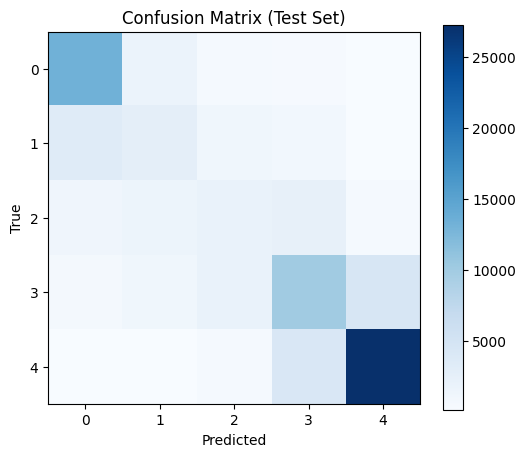

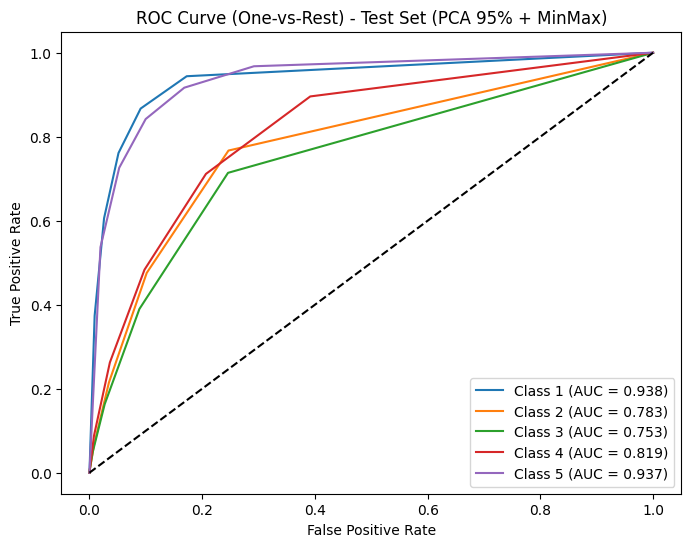

💾 Model saved as /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_pca95_minmax.pkl
💾 AUC-ROC values saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_pca95_minmax_auc.csv
💾 ROC points saved as /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/knn_pca95_minmax_roc_points.csv


In [13]:
# -*- coding: utf-8 -*-
"""KNN_PCA_95_MinMax.ipynb"""

from google.colab import drive
drive.mount('/content/drive')

# =====================================
# 📘 KNN Classification with PCA (95% variance) + MinMaxScaler
# =====================================

import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.decomposition import PCA

# =======================
# === Block 1: Load Data
# =======================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# ==============================
# === Block 2: Split Features
# ==============================
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

# =====================================
# === Block 3: Normalize + PCA (95%)
# =====================================
print("\nBefore PCA:", X_train.shape)

# --- Normalize Features ---
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- Apply PCA (keep 95% variance) ---
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA reduced features from {X_train.shape[1]} to {X_train_pca.shape[1]} dimensions.\n")

# ==========================================
# === Block 4: 10-Fold Cross Validation
# ==========================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

print("=== 10-Fold Cross Validation Results ===")
classes = np.unique(y_train)
start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_pca, y_train), 1):
    X_tr, X_val = X_train_pca[train_idx], X_train_pca[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = KNeighborsClassifier(n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')

    y_val_bin = label_binarize(y_val, classes=sorted(classes))
    y_pred_bin = label_binarize(y_pred, classes=sorted(classes))
    fold_auc = roc_auc_score(y_val_bin, y_pred_bin, average="weighted", multi_class="ovr")

    results.append([fold, acc, prec, rec, f1, fold_auc])
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(fold_auc)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, AUC={fold_auc:.3f}")

# === Summary ===
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print(cv_df)

print("\n📊 Cross-validation (10 folds) Avg Metrics:")
print(f"Accuracy: {np.mean(accuracy_list):.3f}, Precision: {np.mean(precision_list):.3f}, "
      f"Recall: {np.mean(recall_list):.3f}, F1: {np.mean(f1_list):.3f}, AUC: {np.mean(auc_scores):.3f}")

print(f"\n⏱ Completed in {time.time() - start_time:.2f} seconds")

# =====================================
# === Block 5: Final Testing & Report
# =====================================
model.fit(X_train_pca, y_train)
y_pred_test = model.predict(X_test_pca)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(classes))
y_pred_test_bin = label_binarize(y_pred_test, classes=sorted(classes))
test_auc = roc_auc_score(y_test_bin, y_pred_test_bin, average="weighted", multi_class="ovr")

print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=2))

# ==========================================
# === Block6: Confusion Matrix & ROC Curve ===
# ==========================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# --- ROC Curve ---
y_pred_proba_test = model.predict_proba(X_test_pca)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Test Set (PCA 95% + MinMax)')
plt.legend()
plt.show()

# =====================================
# === Block 7: Save Model & AUC Result
# =====================================
base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/all/'

joblib.dump(model, base_path + 'knn_pca95_minmax.pkl')
print(f"💾 Model saved as {base_path}knn_pca95_minmax.pkl")

auc_df = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auc_df.to_csv(base_path + 'knn_pca95_minmax_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}knn_pca95_minmax_auc.csv")

# === Save ROC Curve Points ===
roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})

roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + 'knn_pca95_minmax_roc_points.csv', index=False)
print(f"💾 ROC points saved as {base_path}knn_pca95_minmax_roc_points.csv")